### Advanced Visual Techniques ⭐⭐ - Control charts, Mahalanobis distance, Cook's distance, and residual plots

Advanced visual techniques for anomaly detection and statistical process control. Control charts are widely used in manufacturing for real-time monitoring. Mahalanobis distance detects multivariate outliers. Cook's distance identifies influential points in regression. Residual plots reveal model-based anomalies.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.covariance import MinCovDet
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)

### Shewhart Control Chart - Detecting Shifts in Process Mean

The Shewhart control chart plots individual measurements or subgroup means over time with center line (CL), upper control limit (UCL), and lower control limit (LCL). Points outside 3-sigma limits signal potential anomalies.

**When to use:** Real-time process monitoring, manufacturing quality control, detecting sudden shifts in a stable process.

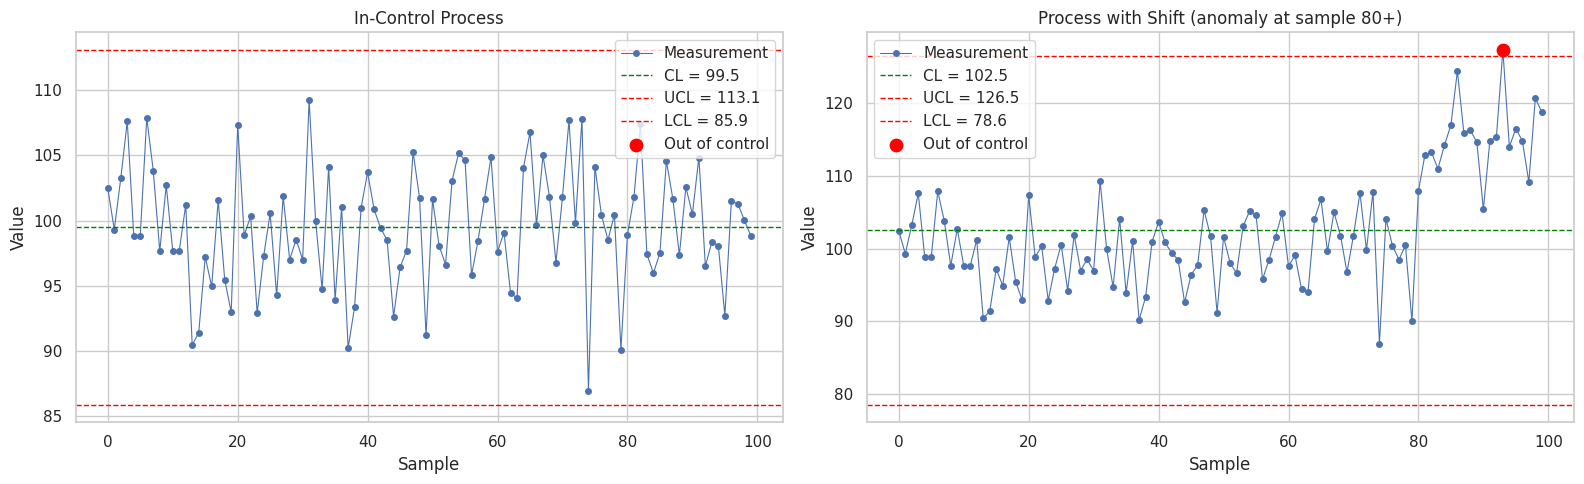

In [10]:
# Generate in-control process data
mu, sigma = 100, 5
n_points = 100
in_control = np.random.normal(mu, sigma, n_points)

# Add a shift anomaly at sample 80
out_of_control = in_control.copy()
out_of_control[80:] = np.random.normal(mu + 3*sigma, sigma, 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title in zip(axes, [in_control, out_of_control],
    ['In-Control Process', 'Process with Shift (anomaly at sample 80+)']):

    mean = np.mean(data)
    std = np.std(data, ddof=1)

    ax.plot(data, 'o-', markersize=4, linewidth=0.8, label='Measurement')
    ax.axhline(mean, color='green', linestyle='--', linewidth=1, label=f'CL = {mean:.1f}')
    ax.axhline(mean + 3*std, color='red', linestyle='--', linewidth=1, label=f'UCL = {mean + 3*std:.1f}')
    ax.axhline(mean - 3*std, color='red', linestyle='--', linewidth=1, label=f'LCL = {mean - 3*std:.1f}')

    # Highlight points outside control limits
    outliers = (data > mean + 3*std) | (data < mean - 3*std)
    ax.scatter(np.where(outliers)[0], data[outliers],
               color='red', s=80, zorder=5, label='Out of control')

    ax.set_xlabel('Sample')
    ax.set_ylabel('Value')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### CUSUM (Cumulative Sum) Control Chart - Detecting Small Shifts

CUSUM accumulates deviations from a target value, making it sensitive to small, persistent shifts that Shewhart charts might miss. It's especially useful when you need to detect subtle process changes early.

**When to use:** Detecting small sustained shifts in manufacturing, financial monitoring, and any process where early detection of drift matters.

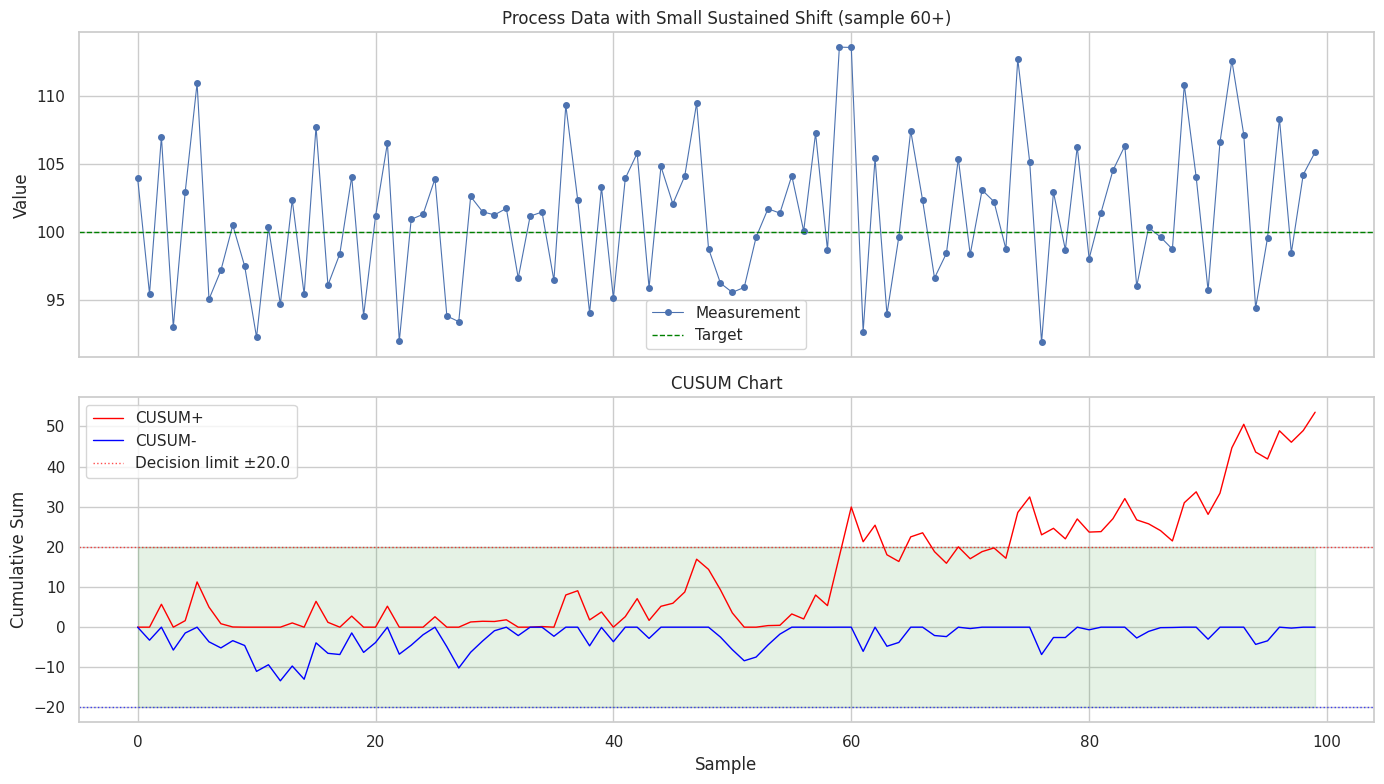

In [11]:
def cusum(data, target, shift=0.5, k=None):
    """Compute CUSUM statistics."""
    std = np.std(data, ddof=1)
    if k is None:
        k = shift * std / 2
    cusum_pos = np.zeros(len(data))
    cusum_neg = np.zeros(len(data))
    for i in range(1, len(data)):
        cusum_pos[i] = max(0, cusum_pos[i-1] + data[i] - target - k)
        cusum_neg[i] = min(0, cusum_neg[i-1] + data[i] - target + k)
    return cusum_pos, cusum_neg

# Generate data with a small sustained shift
n = 100
mu, sigma = 100, 5
data = np.random.normal(mu, sigma, n)
data[60:] = np.random.normal(mu + 2, sigma, 40)  # small +2 shift

cusum_pos, cusum_neg = cusum(data, target=mu)
h = 4 * sigma  # decision interval

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: raw data
ax1.plot(data, 'o-', markersize=4, linewidth=0.8, label='Measurement')
ax1.axhline(mu, color='green', linestyle='--', linewidth=1, label='Target')
ax1.set_ylabel('Value')
ax1.set_title('Process Data with Small Sustained Shift (sample 60+)')
ax1.legend()

# Bottom: CUSUM
ax2.plot(cusum_pos, label='CUSUM+', color='red', linewidth=1)
ax2.plot(cusum_neg, label='CUSUM-', color='blue', linewidth=1)
ax2.axhline(h, color='red', linestyle=':', linewidth=1, alpha=0.7, label=f'Decision limit ±{h:.1f}')
ax2.axhline(-h, color='blue', linestyle=':', linewidth=1, alpha=0.7)
ax2.fill_between(range(n), h, -h, alpha=0.1, color='green')
ax2.set_xlabel('Sample')
ax2.set_ylabel('Cumulative Sum')
ax2.set_title('CUSUM Chart')
ax2.legend()

plt.tight_layout()
plt.show()

### EWMA (Exponentially Weighted Moving Average) Control Chart

EWMA applies exponential weighting to past observations, giving more weight to recent data. It balances responsiveness to shifts with robustness to noise, making it effective for detecting both large and small process changes.

**When to use:** Gradual process drift detection, financial time series monitoring, and situations where you want to smooth noise while remaining sensitive to shifts.

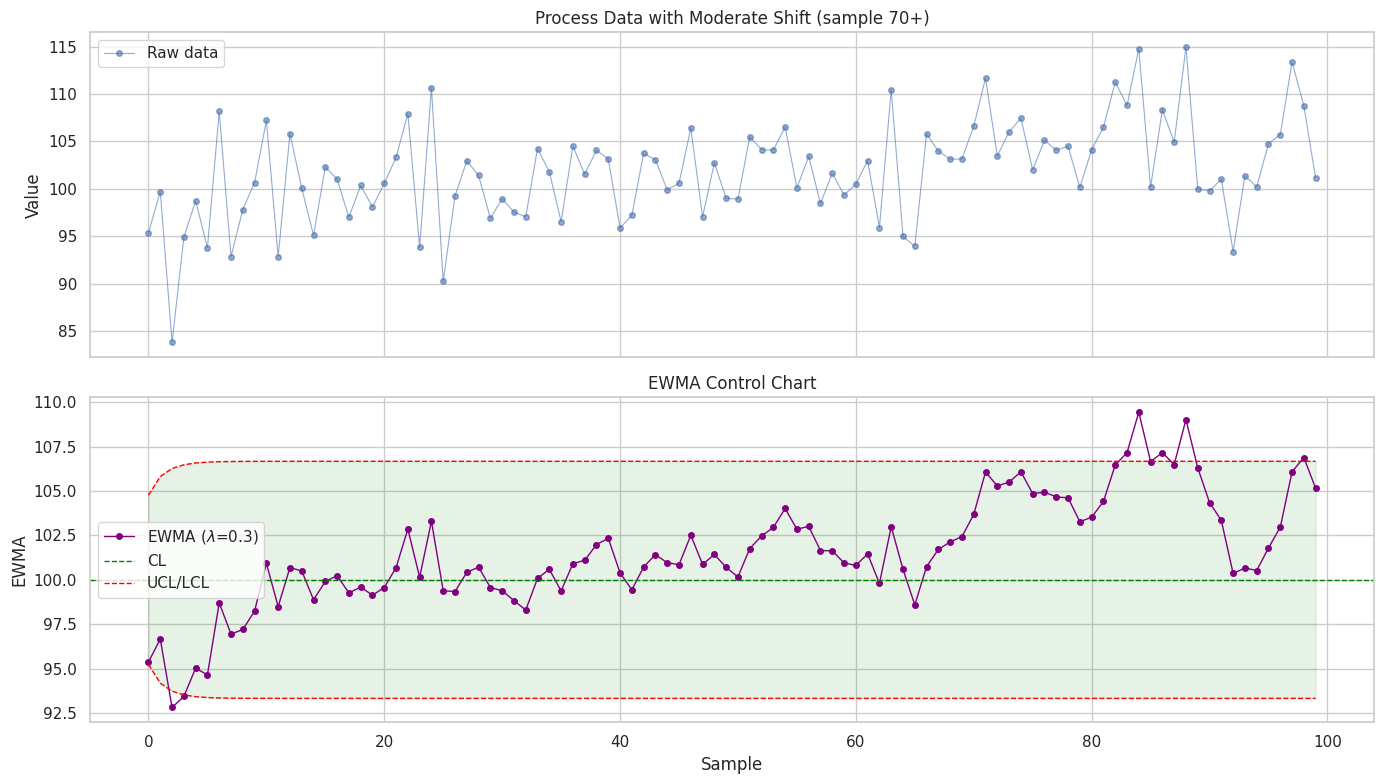

In [12]:
def ewma(data, lambda_=0.2):
    """Compute EWMA statistic."""
    z = np.zeros(len(data))
    z[0] = data[0]
    for i in range(1, len(data)):
        z[i] = lambda_ * data[i] + (1 - lambda_) * z[i-1]
    return z

n = 100
mu, sigma = 100, 5
data = np.random.normal(mu, sigma, n)
data[70:] = np.random.normal(mu + 4, sigma, 30)  # moderate shift

lambda_ = 0.3
z = ewma(data, lambda_=lambda_)

# EWMA control limits
var_factor = lambda_ / (2 - lambda_)
L = 3
std_data = np.std(data, ddof=1)
ucl = mu + L * std_data * np.sqrt(var_factor * (1 - (1 - lambda_)**(2 * np.arange(1, n + 1))))
lcl = mu - L * std_data * np.sqrt(var_factor * (1 - (1 - lambda_)**(2 * np.arange(1, n + 1))))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(data, 'o-', markersize=4, linewidth=0.8, alpha=0.6, label='Raw data')
ax1.set_ylabel('Value')
ax1.set_title('Process Data with Moderate Shift (sample 70+)')
ax1.legend()

ax2.plot(z, 'o-', markersize=4, linewidth=1, color='purple', label=f'EWMA ($\\lambda$={lambda_})')
ax2.axhline(mu, color='green', linestyle='--', linewidth=1, label='CL')
ax2.plot(ucl, color='red', linestyle='--', linewidth=1, label='UCL/LCL')
ax2.plot(lcl, color='red', linestyle='--', linewidth=1)
ax2.fill_between(range(n), ucl, lcl, alpha=0.1, color='green')
ax2.set_xlabel('Sample')
ax2.set_ylabel('EWMA')
ax2.set_title('EWMA Control Chart')
ax2.legend()

plt.tight_layout()
plt.show()

### Mahalanobis Distance - Multivariate Outlier Detection

Mahalanobis distance measures how many standard deviations a point is from the center of a multivariate distribution, accounting for correlations between variables. Unlike Euclidean distance, it captures the shape of the data cloud.

**When to use:** Multivariate outlier detection in correlated data, fraud detection, sensor array validation.

Using Minimum Covariance Determinant (MCD) makes the estimate robust to outliers.

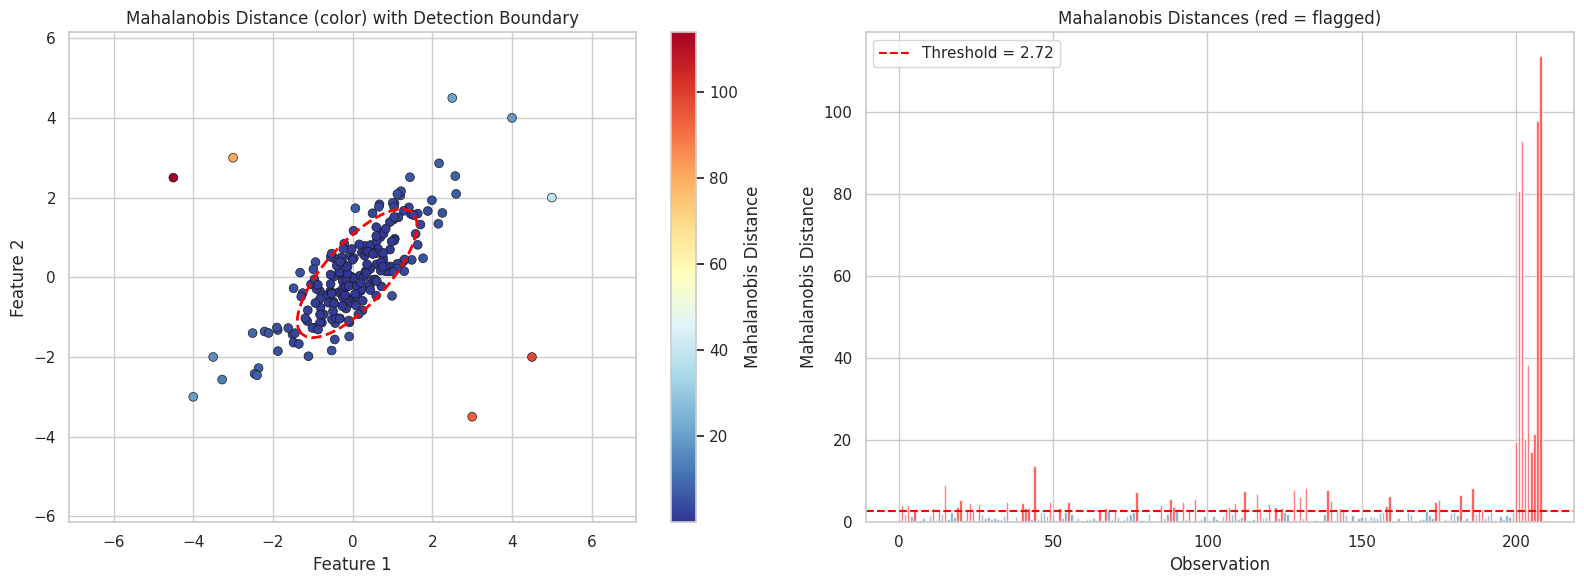

Detected 63 outliers / 209 observations


In [13]:
n_normal = 200

# Generate correlated bivariate normal data
mean = [0, 0]
cov = [[1, 0.8],
       [0.8, 1]]
X = np.random.multivariate_normal(mean, cov, n_normal)

# Inject outliers
outliers = np.array([[4, 4], [-3, 3], [3, -3.5], [-4, -3], [5, 2],
                     [-3.5, -2], [2.5, 4.5], [4.5, -2], [-4.5, 2.5]])
X_all = np.vstack([X, outliers])

# Robust Mahalanobis with MCD
mcd = MinCovDet(random_state=42).fit(X_all)
mahalanobis_dist = mcd.mahalanobis(X_all)

# Threshold (chi-square 2 DOF, 97.5%)
threshold = np.sqrt(stats.chi2.ppf(0.975, df=2))
is_outlier = mahalanobis_dist > threshold

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter with Mahalanobis distance contour
xx, yy = np.meshgrid(np.linspace(-6, 6, 100), np.linspace(-6, 6, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
zdist = mcd.mahalanobis(grid).reshape(xx.shape)

sc = ax1.scatter(X_all[:, 0], X_all[:, 1], c=mahalanobis_dist,
                cmap='RdYlBu_r', s=40, edgecolors='k', linewidth=0.5)
ax1.contour(xx, yy, zdist, levels=[threshold],
           colors='red', linewidths=2, linestyles='--',
           label='Threshold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Mahalanobis Distance (color) with Detection Boundary')
ax1.axis('equal')
plt.colorbar(sc, ax=ax1, label='Mahalanobis Distance')

# Bar plot of distances
colors = ['red' if flag else 'steelblue' for flag in is_outlier]
ax2.bar(range(len(mahalanobis_dist)), mahalanobis_dist, color=colors, alpha=0.7)
ax2.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold = {threshold:.2f}')
ax2.set_xlabel('Observation')
ax2.set_ylabel('Mahalanobis Distance')
ax2.set_title('Mahalanobis Distances (red = flagged)')
ax2.legend()

plt.tight_layout()
plt.show()
print(f'Detected {sum(is_outlier)} outliers / {len(X_all)} observations')

### Cook's Distance - Influence Plots for Regression

Cook's distance measures the influence of each observation on a linear regression model. An observation with high Cook's distance substantially changes the fitted coefficients when removed. It combines leverage (how extreme X is) with residual size.

**When to use:** Regression diagnostics, identifying influential data points, model validation, and data cleaning before modeling.

**Rule of thumb:** Points with $D_i > 4/n$ (where n = sample size) warrant investigation.

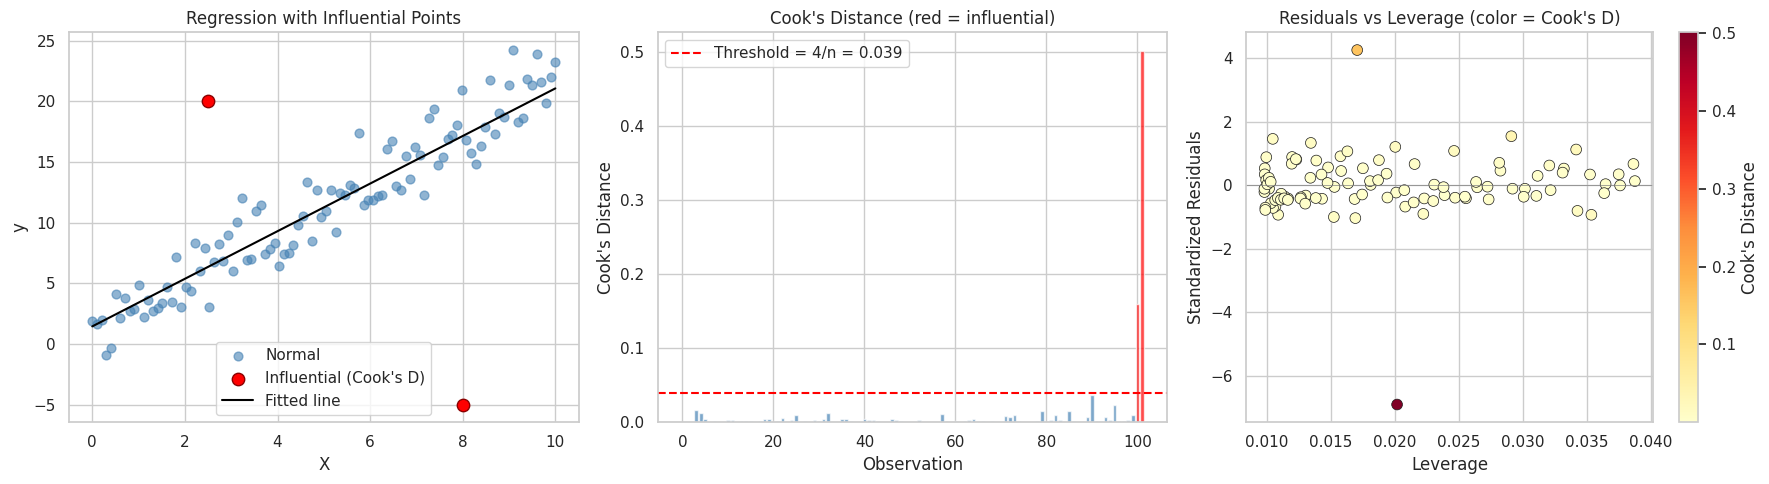

In [14]:
n = 100
X = np.linspace(0, 10, n)
y = 2 * X + 1 + np.random.normal(0, 2, n)

# Inject influential outliers
X_outliers = np.array([2.5, 8.0])
y_outliers = np.array([20, -5])
X_all = np.concatenate([X, X_outliers])
y_all = np.concatenate([y, y_outliers])

# Fit model with all data
model = LinearRegression()
model.fit(X_all.reshape(-1, 1), y_all)
y_pred = model.predict(X_all.reshape(-1, 1))

# Compute Cook's distance
n_pts = len(X_all)
p = 2
residuals = y_all - y_pred
mse = np.sum(residuals**2) / (n_pts - p)

# Hat matrix diagonal (leverage)
X_design = np.column_stack([np.ones(n_pts), X_all])
H = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T
leverage = np.diag(H)

cooks_d = residuals**2 / (p * mse) * leverage / (1 - leverage)**2

threshold = 4 / n_pts
influential = cooks_d > threshold

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Regression line with influential points
ax1.scatter(X_all[~influential], y_all[~influential],
           color='steelblue', s=40, alpha=0.6, label='Normal')
ax1.scatter(X_all[influential], y_all[influential],
           color='red', s=80, edgecolors='darkred', linewidth=1,
           label="Influential (Cook's D)")
ax1.plot(np.sort(X_all), model.predict(np.sort(X_all).reshape(-1, 1)),
        color='black', linewidth=1.5, label='Fitted line')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Regression with Influential Points')
ax1.legend()

# Plot 2: Cook's distance bar plot
bar_colors = ['red' if flag else 'steelblue' for flag in influential]
ax2.bar(range(n_pts), cooks_d, color=bar_colors, alpha=0.7)
ax2.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold = 4/n = {threshold:.3f}')
ax2.set_xlabel('Observation')
ax2.set_ylabel("Cook's Distance")
ax2.set_title("Cook's Distance (red = influential)")
ax2.legend()

# Plot 3: Residuals vs leverage with Cook's distance contours
standardized_residuals = residuals / np.sqrt(mse)
sc_cd = ax3.scatter(leverage, standardized_residuals, c=cooks_d,
                    cmap='YlOrRd', s=60, edgecolors='k', linewidth=0.5)
ax3.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Leverage')
ax3.set_ylabel('Standardized Residuals')
ax3.set_title('Residuals vs Leverage (color = Cook\'s D)')
plt.colorbar(sc_cd, ax=ax3, label="Cook's Distance")

plt.tight_layout()
plt.show()

### Residual Plots - Model-Based Anomaly Visualization

Residual plots help diagnose model fit and detect anomalies that the model cannot explain. Key patterns: random scatter around zero indicates good fit; systematic patterns (curvature, increasing spread) suggest model misspecification; isolated large residuals indicate anomalies.

**When to use:** Model validation, anomaly detection after regression, checking assumptions (homoscedasticity, linearity, normality of errors).

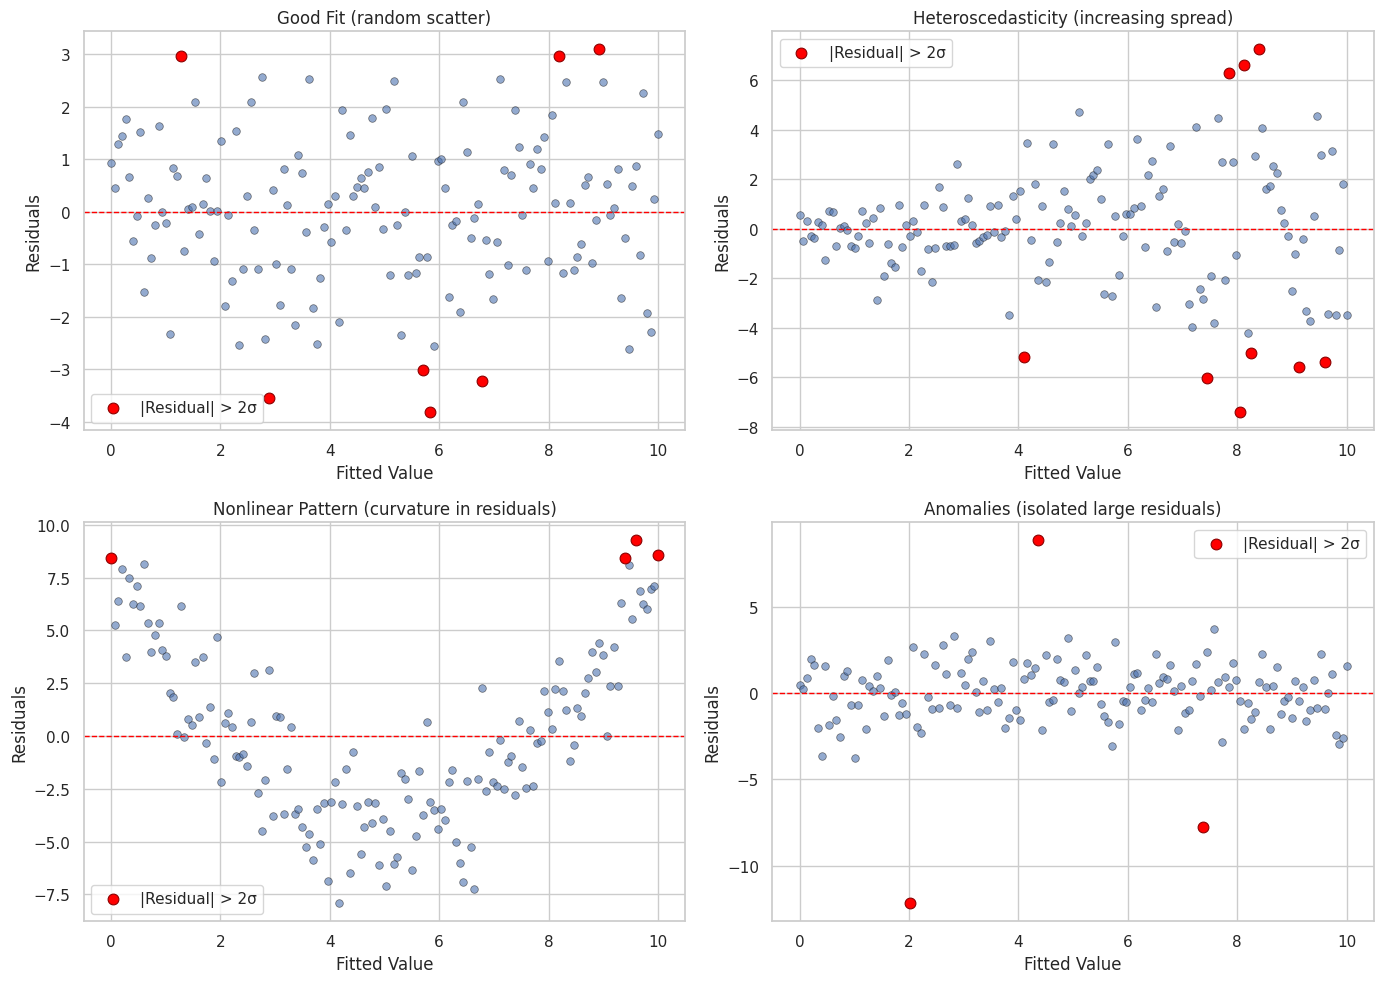

In [15]:
n = 150
x = np.linspace(0, 10, n)

# 1. Good fit (homoscedastic, no pattern)
y1 = 2 * x + 1 + np.random.normal(0, 1.5, n)
model1 = LinearRegression().fit(x.reshape(-1, 1), y1)
res1 = y1 - model1.predict(x.reshape(-1, 1))

# 2. Heteroscedastic (increasing spread)
y2 = 2 * x + 1 + np.random.normal(0, 0.5 + 0.3 * x, n)
model2 = LinearRegression().fit(x.reshape(-1, 1), y2)
res2 = y2 - model2.predict(x.reshape(-1, 1))

# 3. Nonlinear pattern
y3 = 0.5 * x**2 - 3 * x + 5 + np.random.normal(0, 2, n)
model3 = LinearRegression().fit(x.reshape(-1, 1), y3)
res3 = y3 - model3.predict(x.reshape(-1, 1))

# 4. With isolated anomalies
y4 = 2 * x + 1 + np.random.normal(0, 1.5, n)
y4[[30, 65, 110]] += np.array([-12, 10, -8])
model4 = LinearRegression().fit(x.reshape(-1, 1), y4)
res4 = y4 - model4.predict(x.reshape(-1, 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = ['Good Fit (random scatter)',
          'Heteroscedasticity (increasing spread)',
          'Nonlinear Pattern (curvature in residuals)',
          'Anomalies (isolated large residuals)']
xs = [x, x, x, x]
all_res = [res1, res2, res3, res4]
all_ys = [y1, y2, y3, y4]

for ax, xi, ri, yi, title in zip(axes.flat, xs, all_res, all_ys, titles):
    # Residual plot
    ax.scatter(xi, ri, alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)

    # Highlight large residuals
    std_r = np.std(ri)
    large = np.abs(ri) > 2 * std_r
    ax.scatter(xi[large], ri[large], color='red', s=60,
              edgecolors='darkred', linewidth=0.8, label='|Residual| > 2σ')

    ax.set_xlabel('Fitted Value')
    ax.set_ylabel('Residuals')
    ax.set_title(title)
    if large.any():
        ax.legend()

plt.tight_layout()
plt.show()